# Machine Learning Classification Project: Predicting Personality Type (Extrovert vs Introvert)

## Dataset: Personality Behavior Dataset


## Objective: To predict whether a person is introvert or extrovert based on behavioral features using machine learning techniques.

# **1. Import Libraries**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **2. Load Dataset**

In [ ]:
# Loading Dataset
df = pd.read_csv("/content/personality_datasert.csv")

print(df.head())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0               4.0         No                      4.0            6.0   
1               9.0        Yes                      0.0            0.0   
2               9.0        Yes                      1.0            2.0   
3               0.0         No                      6.0            7.0   
4               3.0         No                      9.0            4.0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                 13.0             5.0   Extrovert  
1                       Yes                  0.0             3.0   Introvert  
2                       Yes                  5.0             2.0   Introvert  
3                        No                 14.0             8.0   Extrovert  
4                        No                  8.0             5.0   Extrovert  


# **5. EDA**

In [ ]:
# Summary Statistics
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [ ]:
df.shape

(2900, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [ ]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

# **3. Data Cleaning**

In [ ]:
# Checking Missing Values
print(df.isnull().sum())

# Removing Duplicates
df = df.drop_duplicates()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


#  **4. Data** **Preprocessing**

In [ ]:
# Encoding Categorical Columns
df['Stage_fear'] = df['Stage_fear'].map({'Yes':1, 'No':0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes':1, 'No':0})

In [ ]:
df['Personality'] = df['Personality'].map({
    'Introvert':0,
    'Extrovert':1
})

# **6. Data Visualization**

In [ ]:


# Beautiful theme
sns.set_style("whitegrid")

# Color palette
sns.set_palette("Set2")

## **Pairplot**

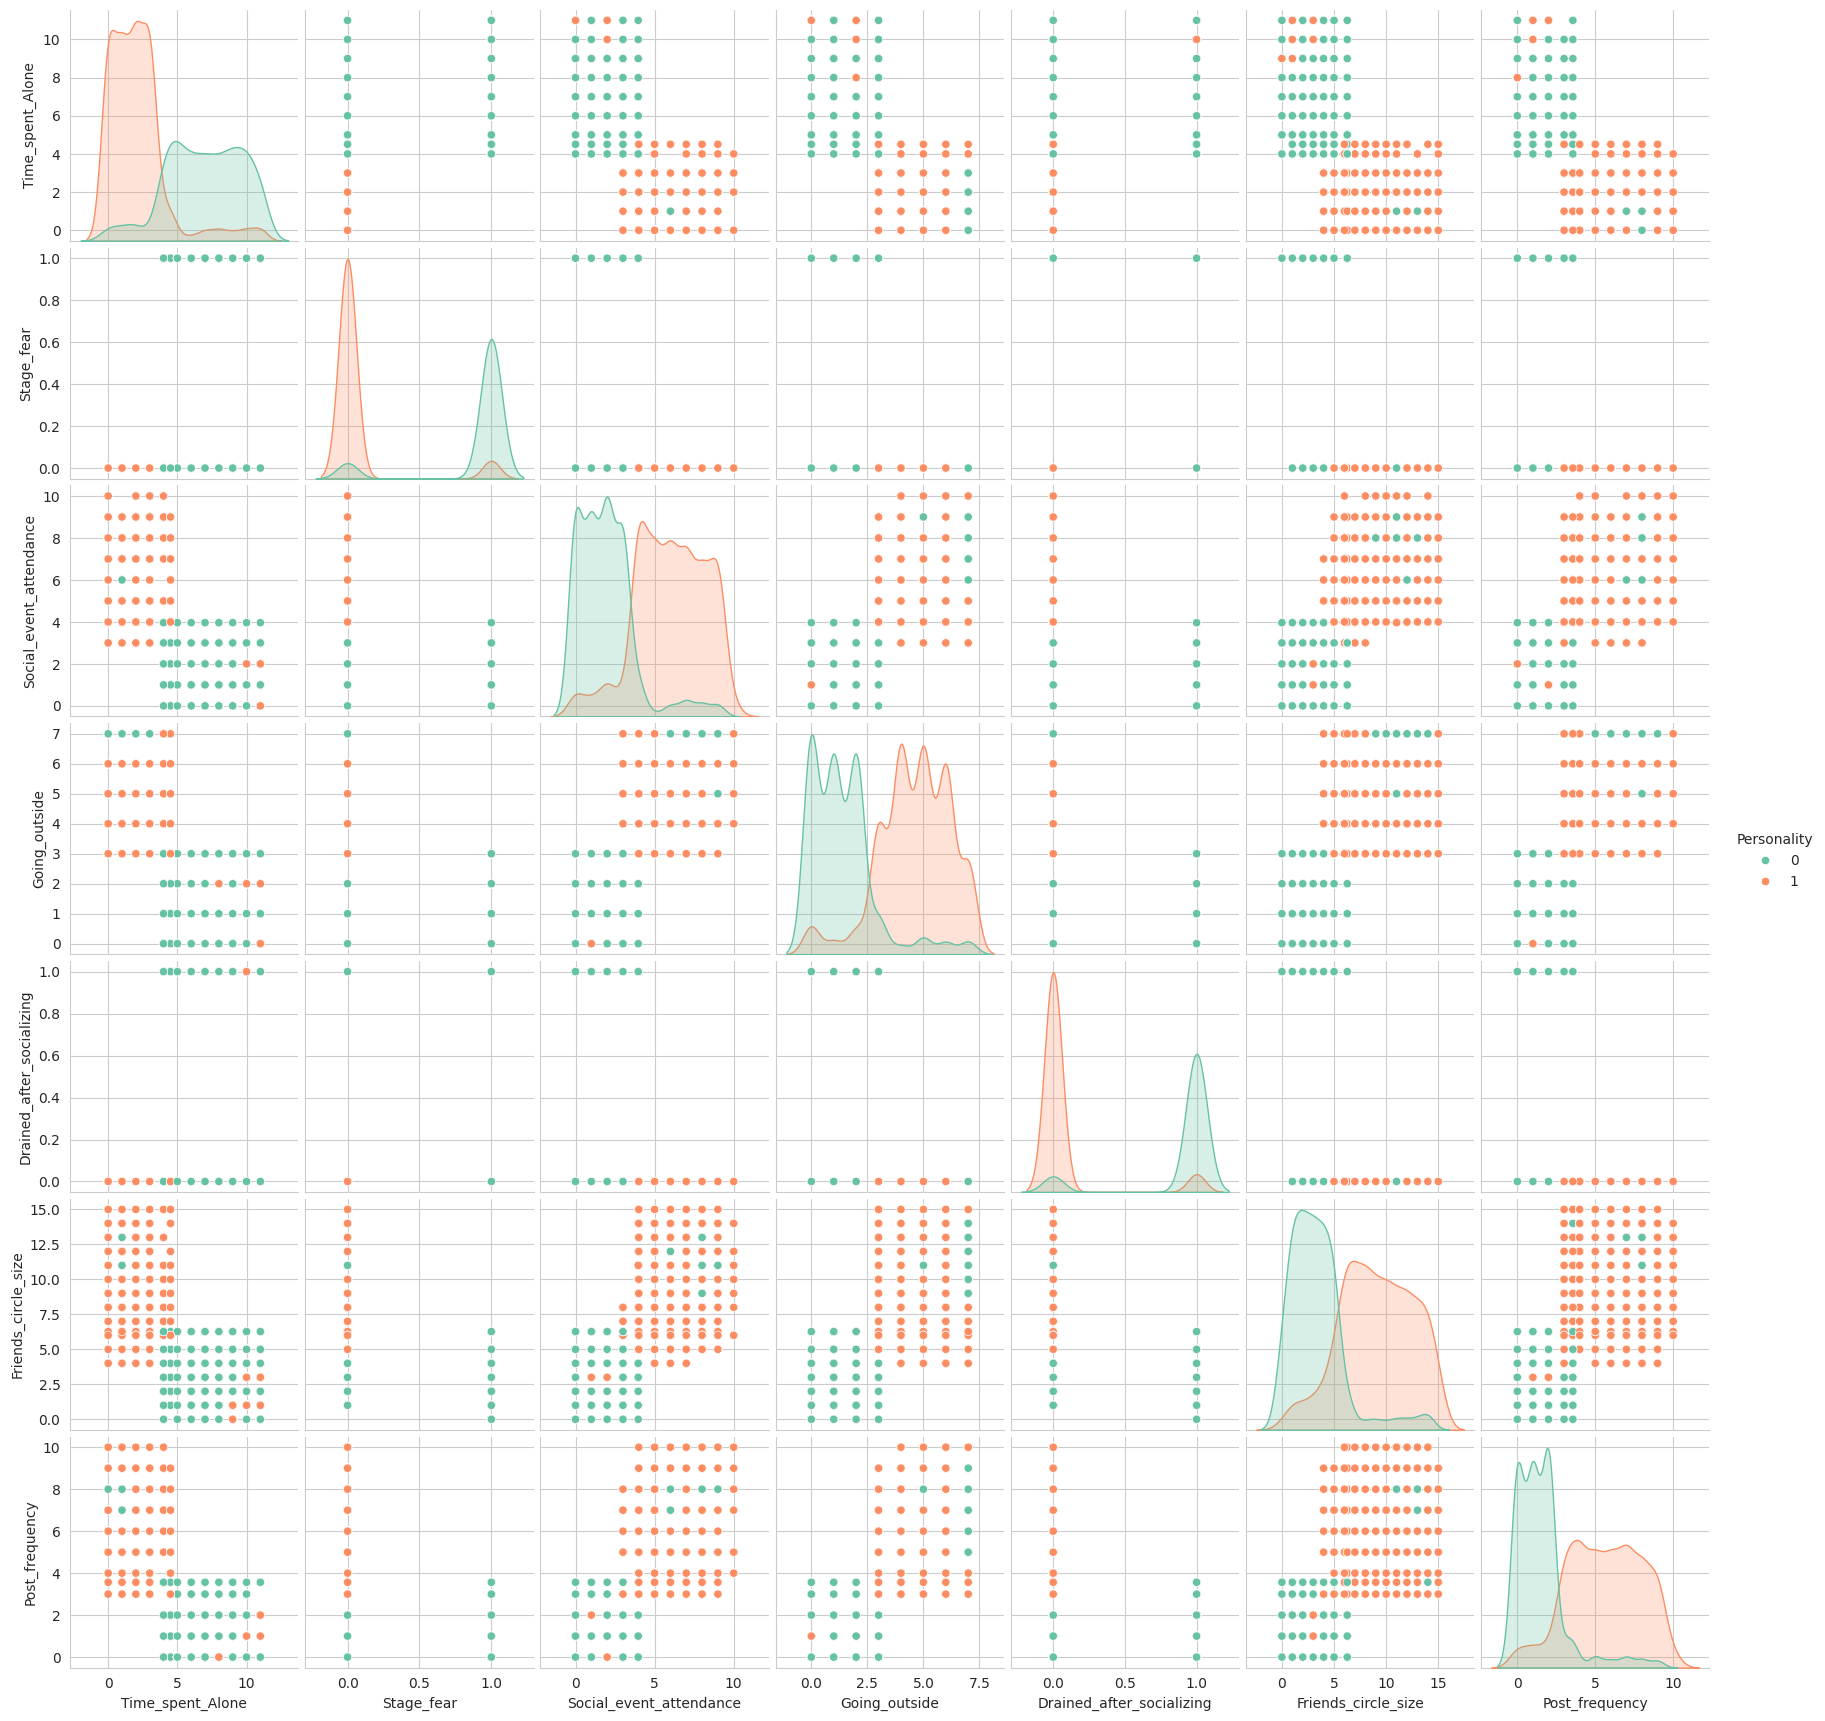

In [ ]:
sns.pairplot(df, hue='Personality')
plt.show()

## **Bar Plot**

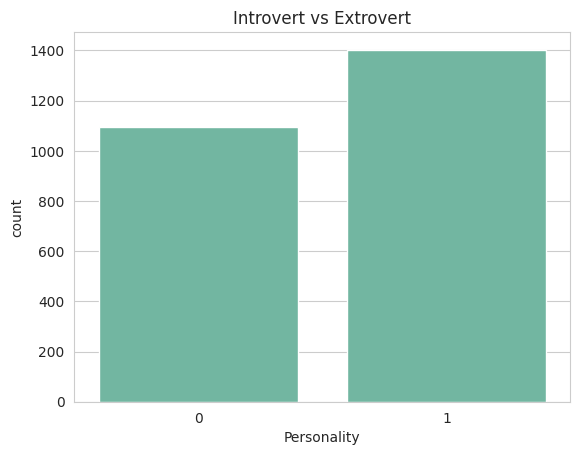

In [ ]:

sns.countplot(x='Personality', data=df)
plt.title("Introvert vs Extrovert")
plt.show()

## **Heatmap**

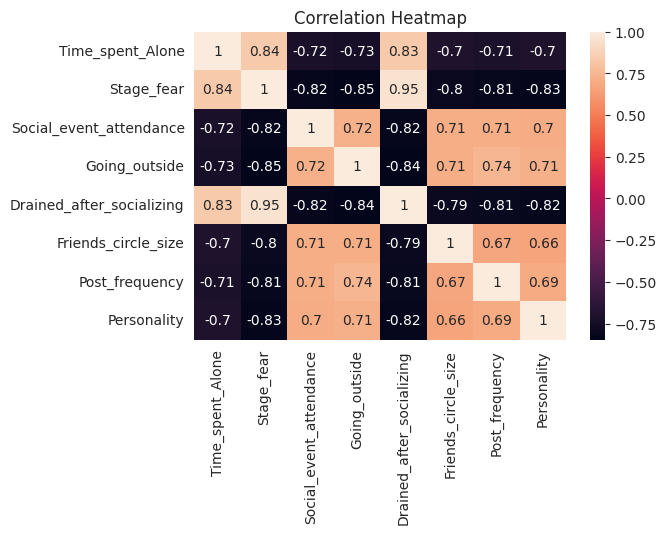

In [ ]:
# Correlation Heatmap (only numeric data)
num_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(6,4))
sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## **Scatter Plot**

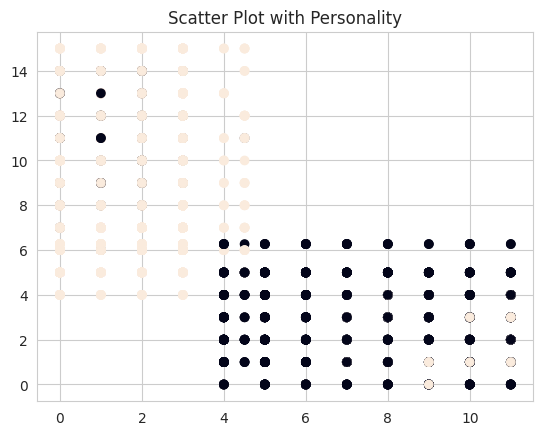

In [ ]:
plt.scatter(df['Time_spent_Alone'], df['Friends_circle_size'], c=df['Personality'])
plt.title("Scatter Plot with Personality")
plt.show()

# **7. Feature Selection**

In [ ]:
X = df.drop('Personality', axis=1)
y = df['Personality']

# **8. Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **9. Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **10. Model Building**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()
model3 = RandomForestClassifier()

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

RandomForestClassifier()

# **11. Prediction**

In [ ]:
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

# **12. Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)

print("Logistic Regression:", acc1)
print("Decision Tree:", acc2)
print("Random Forest:", acc3)

Logistic Regression: 0.904
Decision Tree: 0.834
Random Forest: 0.88


# **13. Confusion Matrix (Best Model)**

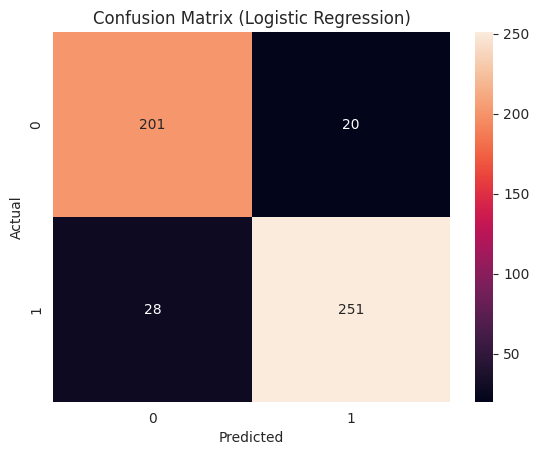

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred1)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

# **14. Model Comparison**

In [ ]:
print("LR:", acc1)
print("DT:", acc2)
print("RF:", acc3)

if acc1 > acc2 and acc1 > acc3:
    print("Best Model: Logistic Regression")
elif acc2 > acc1 and acc2 > acc3:
    print("Best Model: Decision Tree")
else:
    print("Best Model: Random Forest")

LR: 0.904
DT: 0.834
RF: 0.88
Best Model: Logistic Regression
